# TP2 Algèbre : Transformation et Diagonalisation (4h)

<u>***Un compte rendu est à déposer sur e-campus à la fin de la séance***</u>. *Il doit être rédigé directement dans ce document avec votre code que vous pourrez executer à partir de ce fichier section par section.*

*Il vous est demandé de montrer les résultats, de les analyser et les interpréter tout en répondant aux questions. Nous jugerons vos capacités à comprendre et interpréter mathématiquement les réalisations.*

**Assurez-vous toujours de la lisibilité des graphiques : intitulés des axes, légende, échelle, etc.**

<u>***Avant de rendre votre travail :***</u>
* ✅ *Exécutez toutes les cellules*
* ✅ *Assurez vous que tous vos résultats/figures sont bien visibles*
* ✅ *Exportez le fichier en format **pdf***
* ✅ *Déposez le **pdf** sur e-campus*

In [282]:
import numpy as np
import matplotlib.pyplot as plt

🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹

## 1- Calcul de l'image d'un vecteur

### 1.1 Transformation linéaire 2D

On souhaite pouvoir afficher un vecteur et son image par l’application linéaire décrite par la matrice $M$ suivante:

$M=\begin{pmatrix}
5/4 & 0 \\
-1/2 & 3/4
\end{pmatrix}
$

🧩 Ecrire une fonction `transformation` qui admet en entrée la matrice $M$, ainsi qu'un vecteur donné que l’on appellera $X$. Elle calcule et retourne la transformée $Y$ telle que $Y = M * X$. La fonction affichera sur une figure le vecteur $X$ de départ en bleu et le vecteur d’arrivée $Y$ en rouge.

In [283]:
#*******************************************************************************
# écrire ici le code qui transforme X en Y tel que Y = M*X et trace les
# deux vecteurs
#*******************************************************************************

def transformation(M, X):
    M = np.asarray(M)

    Y = np.dot(M, X)
    dim = X.shape[0]

    # 2D
    if dim == 2:
        plt.figure()

        # X
        plt.quiver(0, 0, X[0], X[1], angles='xy', scale_units='xy', scale=1, color='blue', label='X')

        # Y
        plt.quiver(0, 0, Y[0], Y[1], angles='xy', scale_units='xy', scale=1, color='red', label='Y')

        plt.xlim(min(0, X[0], Y[0]) - 1, max(X[0], Y[0]) + 1)
        plt.ylim(min(0, X[1], Y[1]) - 1, max(X[1], Y[1]) + 1)
        plt.axhline(0)
        plt.axvline(0)
        plt.grid()
        plt.legend()
        plt.gca().set_aspect('equal', adjustable='box')
        plt.show()

    # 3D
    elif dim == 3:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')

        ax.quiver(0, 0, 0, X[0], X[1], X[2], color='blue', label='X')
        ax.quiver(0, 0, 0, Y[0], Y[1], Y[2], color='red', label='Y')

        max_val = max(np.max(np.abs(X)), np.max(np.abs(Y))) + 1
        ax.set_xlim(-max_val, max_val)
        ax.set_ylim(-max_val, max_val)
        ax.set_zlim(-max_val, max_val)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        ax.legend()
        plt.show()

    return Y

🧩Testez votre fonction avec quelques vecteurs de votre choix en complétant le programme ci-dessous  

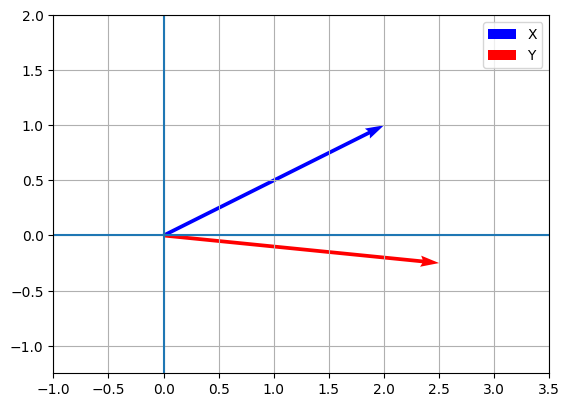

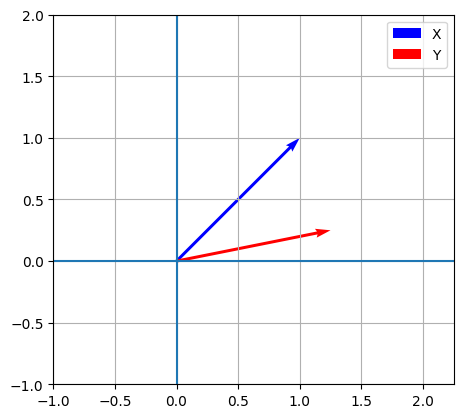

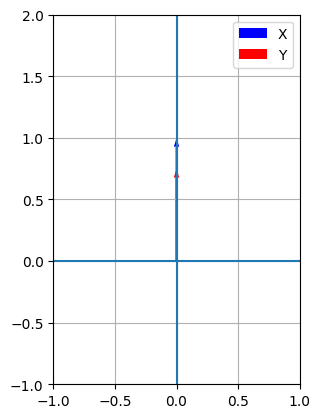

In [284]:
#*******************************************************************************
# écrire ici le code qui appelle la fonction transformation avec des
# vecteurs de votres choix
#******************************************************************************
#définir le vecteur X
X = np.array([2, 1])

#--------------------------------------------------
# définir la matrice M
M = np.array([[5/4, 0], [-1/2, 3/4]])

#--------------------------------------------------
# appeler la fonction transformation
Y = transformation(M, X)

#--------------------------------------------------
# Définir d'autres vecteurs X et appeler la fonction
X = np.array([1, 1])
Y = transformation(M, X)

X = np.array([0, 1])
Y = transformation(M, X)

En vous servant de votre code répondez aux questions suivantes:

❓Le vecteur [1 ,1] est-il un vecteur propre de M ? pourquoi ?

Le vecteur [1, 1] n'est pas un vecteur propre de M, car X et Y ne sont pas colinéaire entre-eux (graphiquement).

❓Le vecteur [0 , 1] est-il un vecteur propre de M ? pourquoi ?  

Le vecteur [0, 1] est un vecteur propre de M car X et Y sont colinéaire entre-eux (graphiquement).

On peut également prouver que ce vecteur est un vecteur propre, via le calcul de vecteur propre effectué en trouvant les racines ci-dessous.

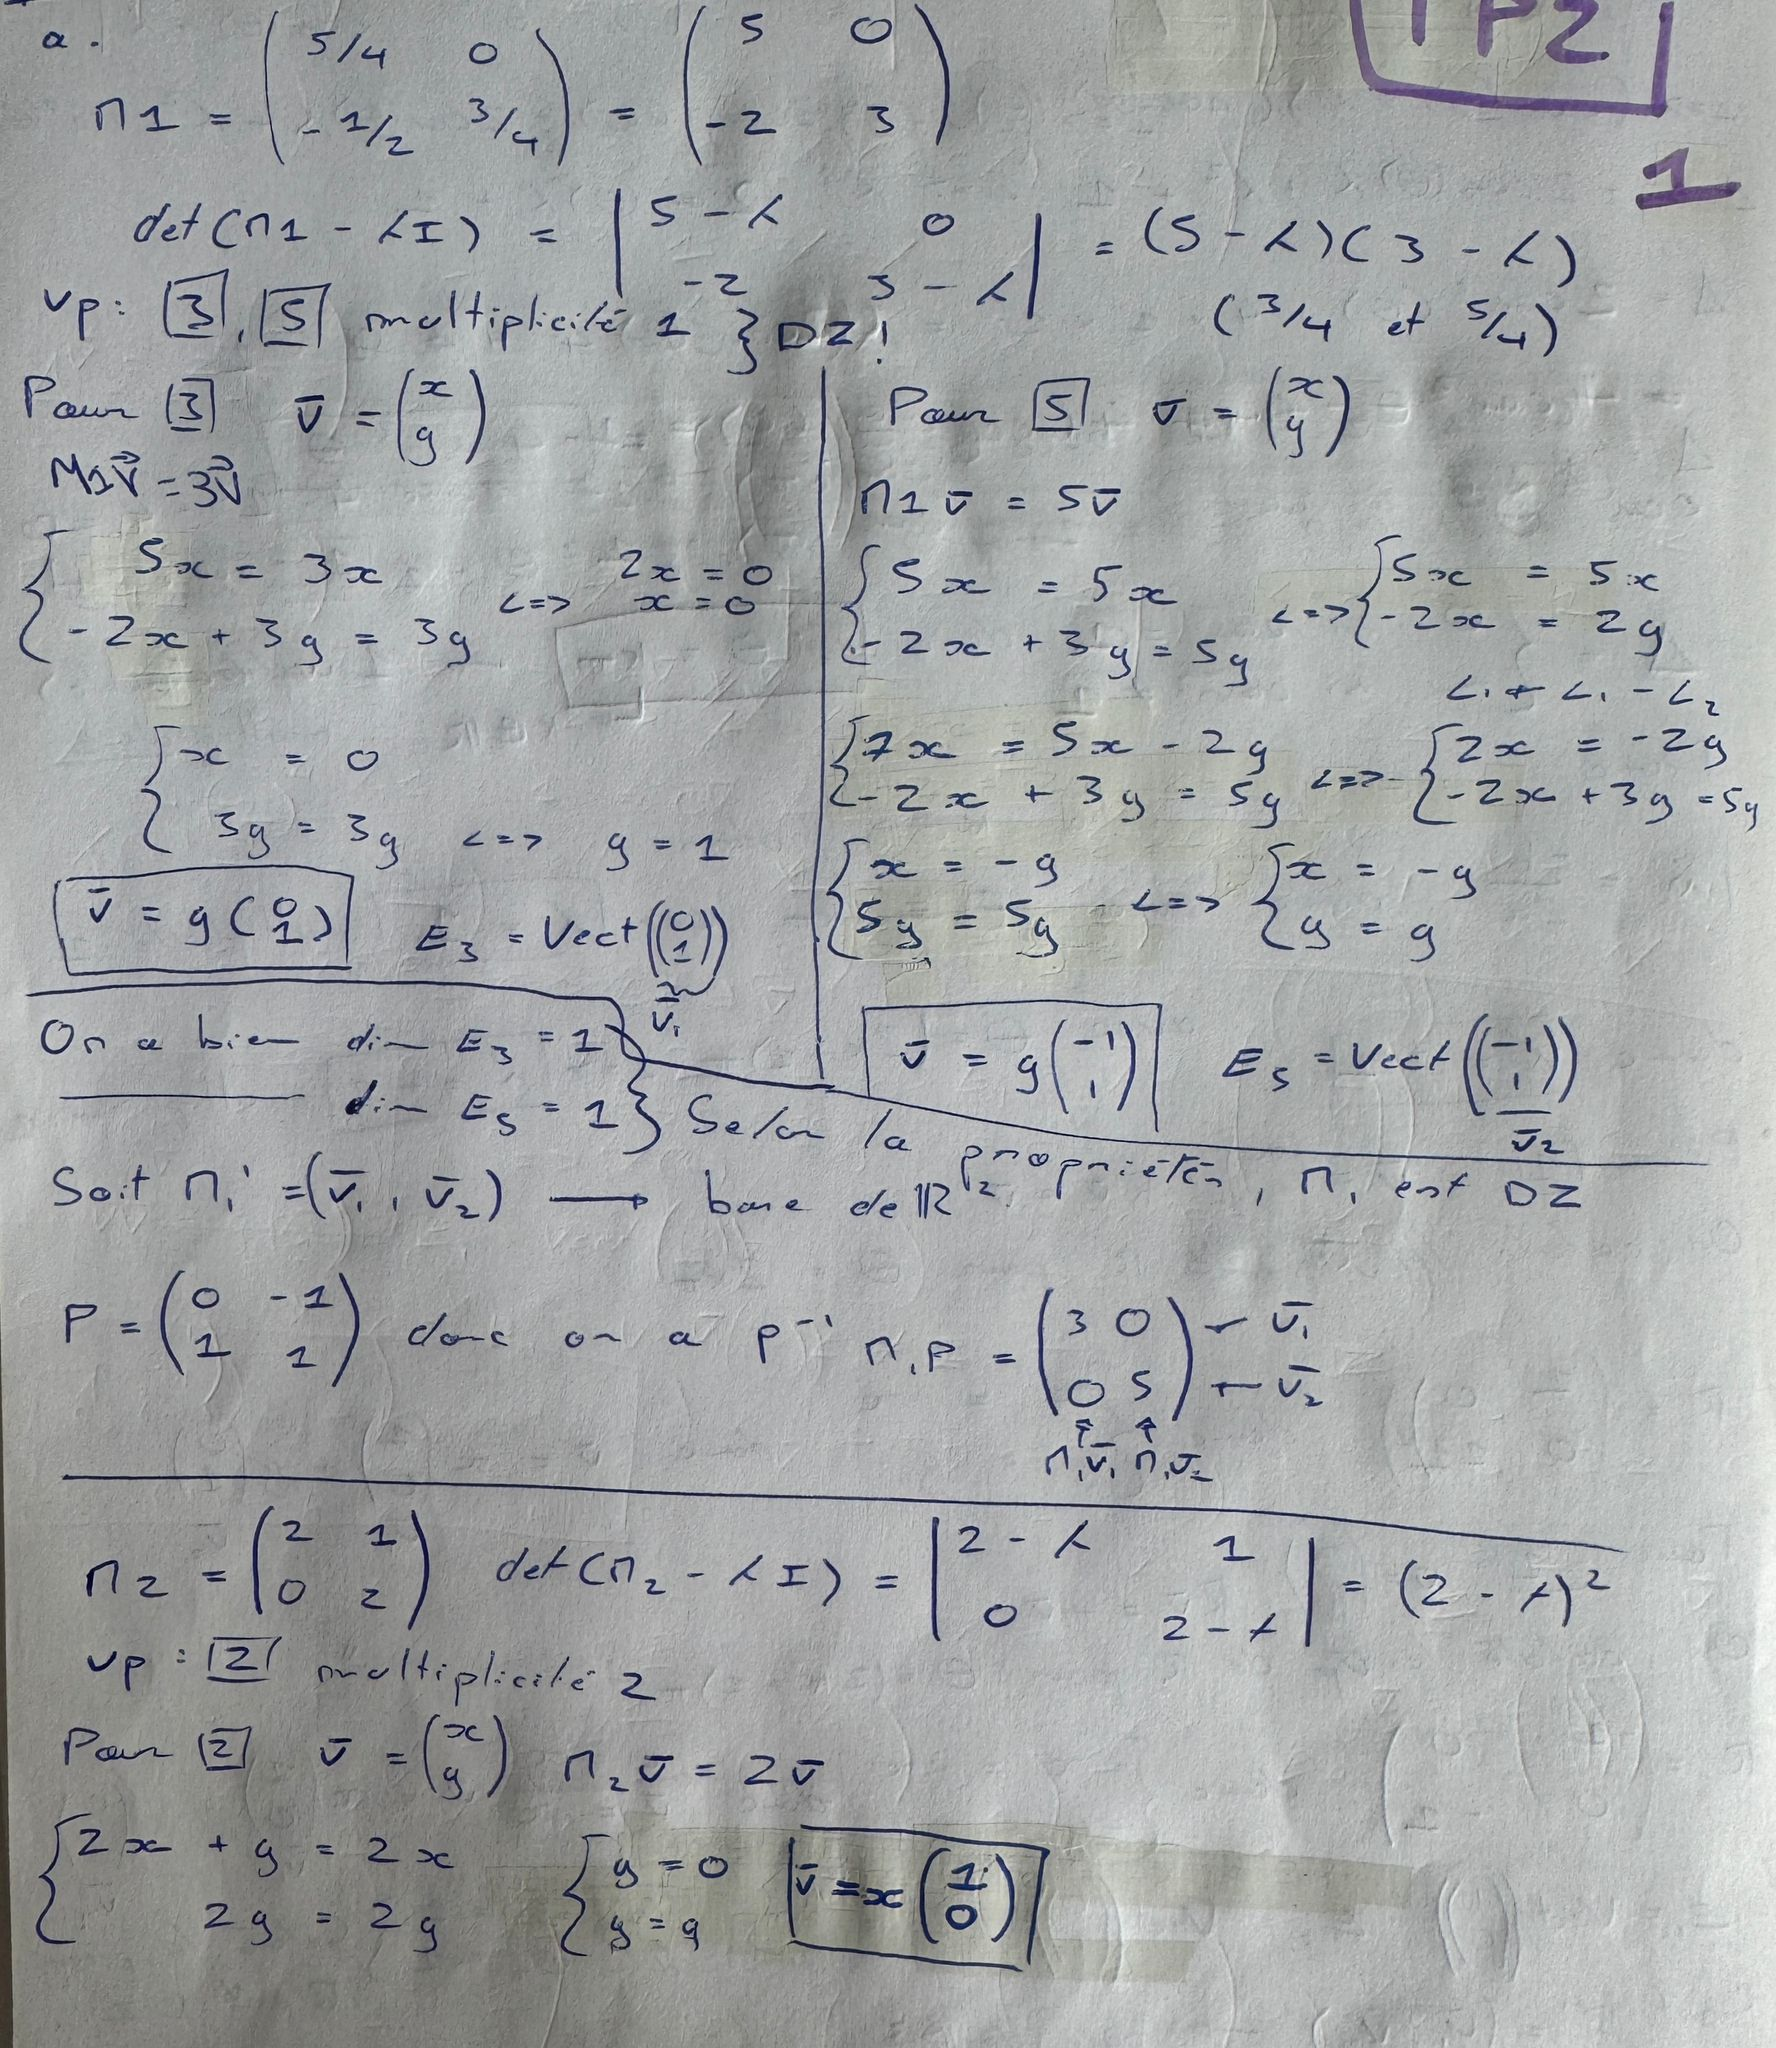

### 1.2 Transformation linéaire 2D : cas particulier

On propose maintenant de modifier la matrice de transformation. Au lieu de $M$ définie précédemment, on souahite utiliser $R$ telle que:

$R = \begin{pmatrix}
cos(\theta) & -sin(\theta) \\
sin(\theta) & cos(\theta)
\end{pmatrix}$

🧩Testez votre programme de transformation avec différentes valeurs de $\theta$

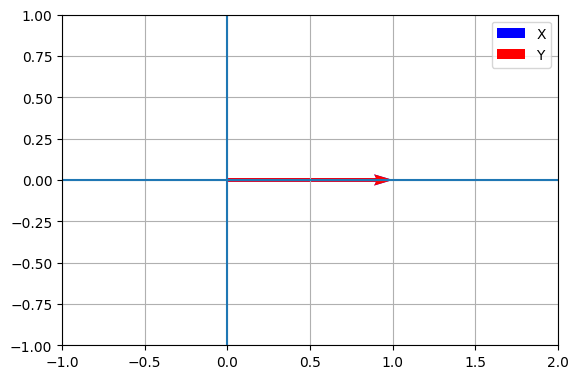

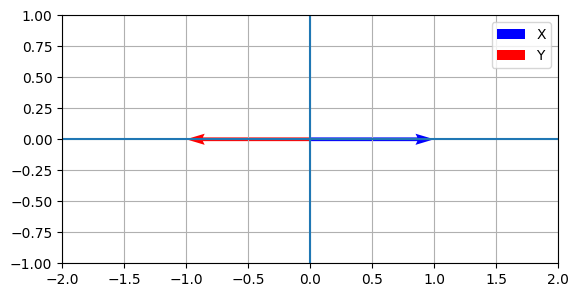

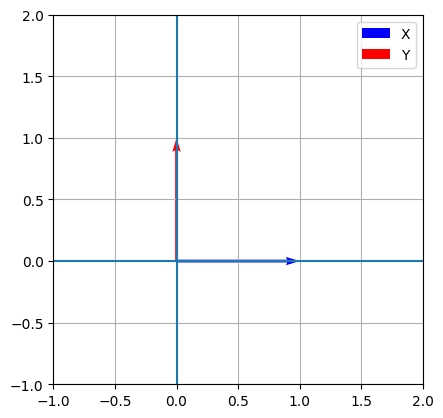

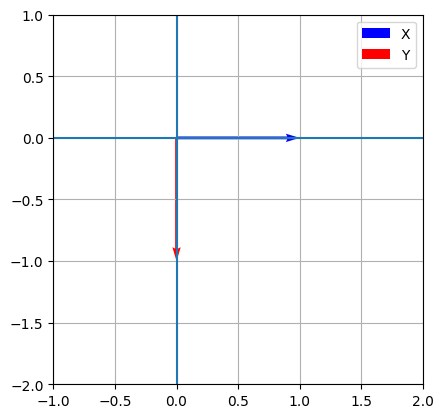

In [285]:
#*******************************************************************************
# écrire ci dessous le code qui effectue des transformations par la matrice R
#******************************************************************************

def R(theta):
    return np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])

X = np.array([1, 0])
M = R(2 * np.pi) # Avec 2pi (colinéaire dans Réels) (0 dégrés)
Y = transformation(M, X)
M = R(np.pi) # Avec pi (colinéaire dans Réels) (180 degrés)
Y = transformation(M, X)
M = R(np.pi / 2) # pi/2 (90 degrés)
Y = transformation(M, X)
M = R(3 * np.pi / 2) # pi/2 (270 degrés)
Y = transformation(M, X)

✏️Faites le calcul sur papier pour les vecteurs unitaires avec $\theta$ quelconque (vous pouvez ensuite insérer une photo de vos calculs dans ce document ou écrire directement les équations ici) et représentez les vecteurs résultants sur le cercle trigonomitrique.

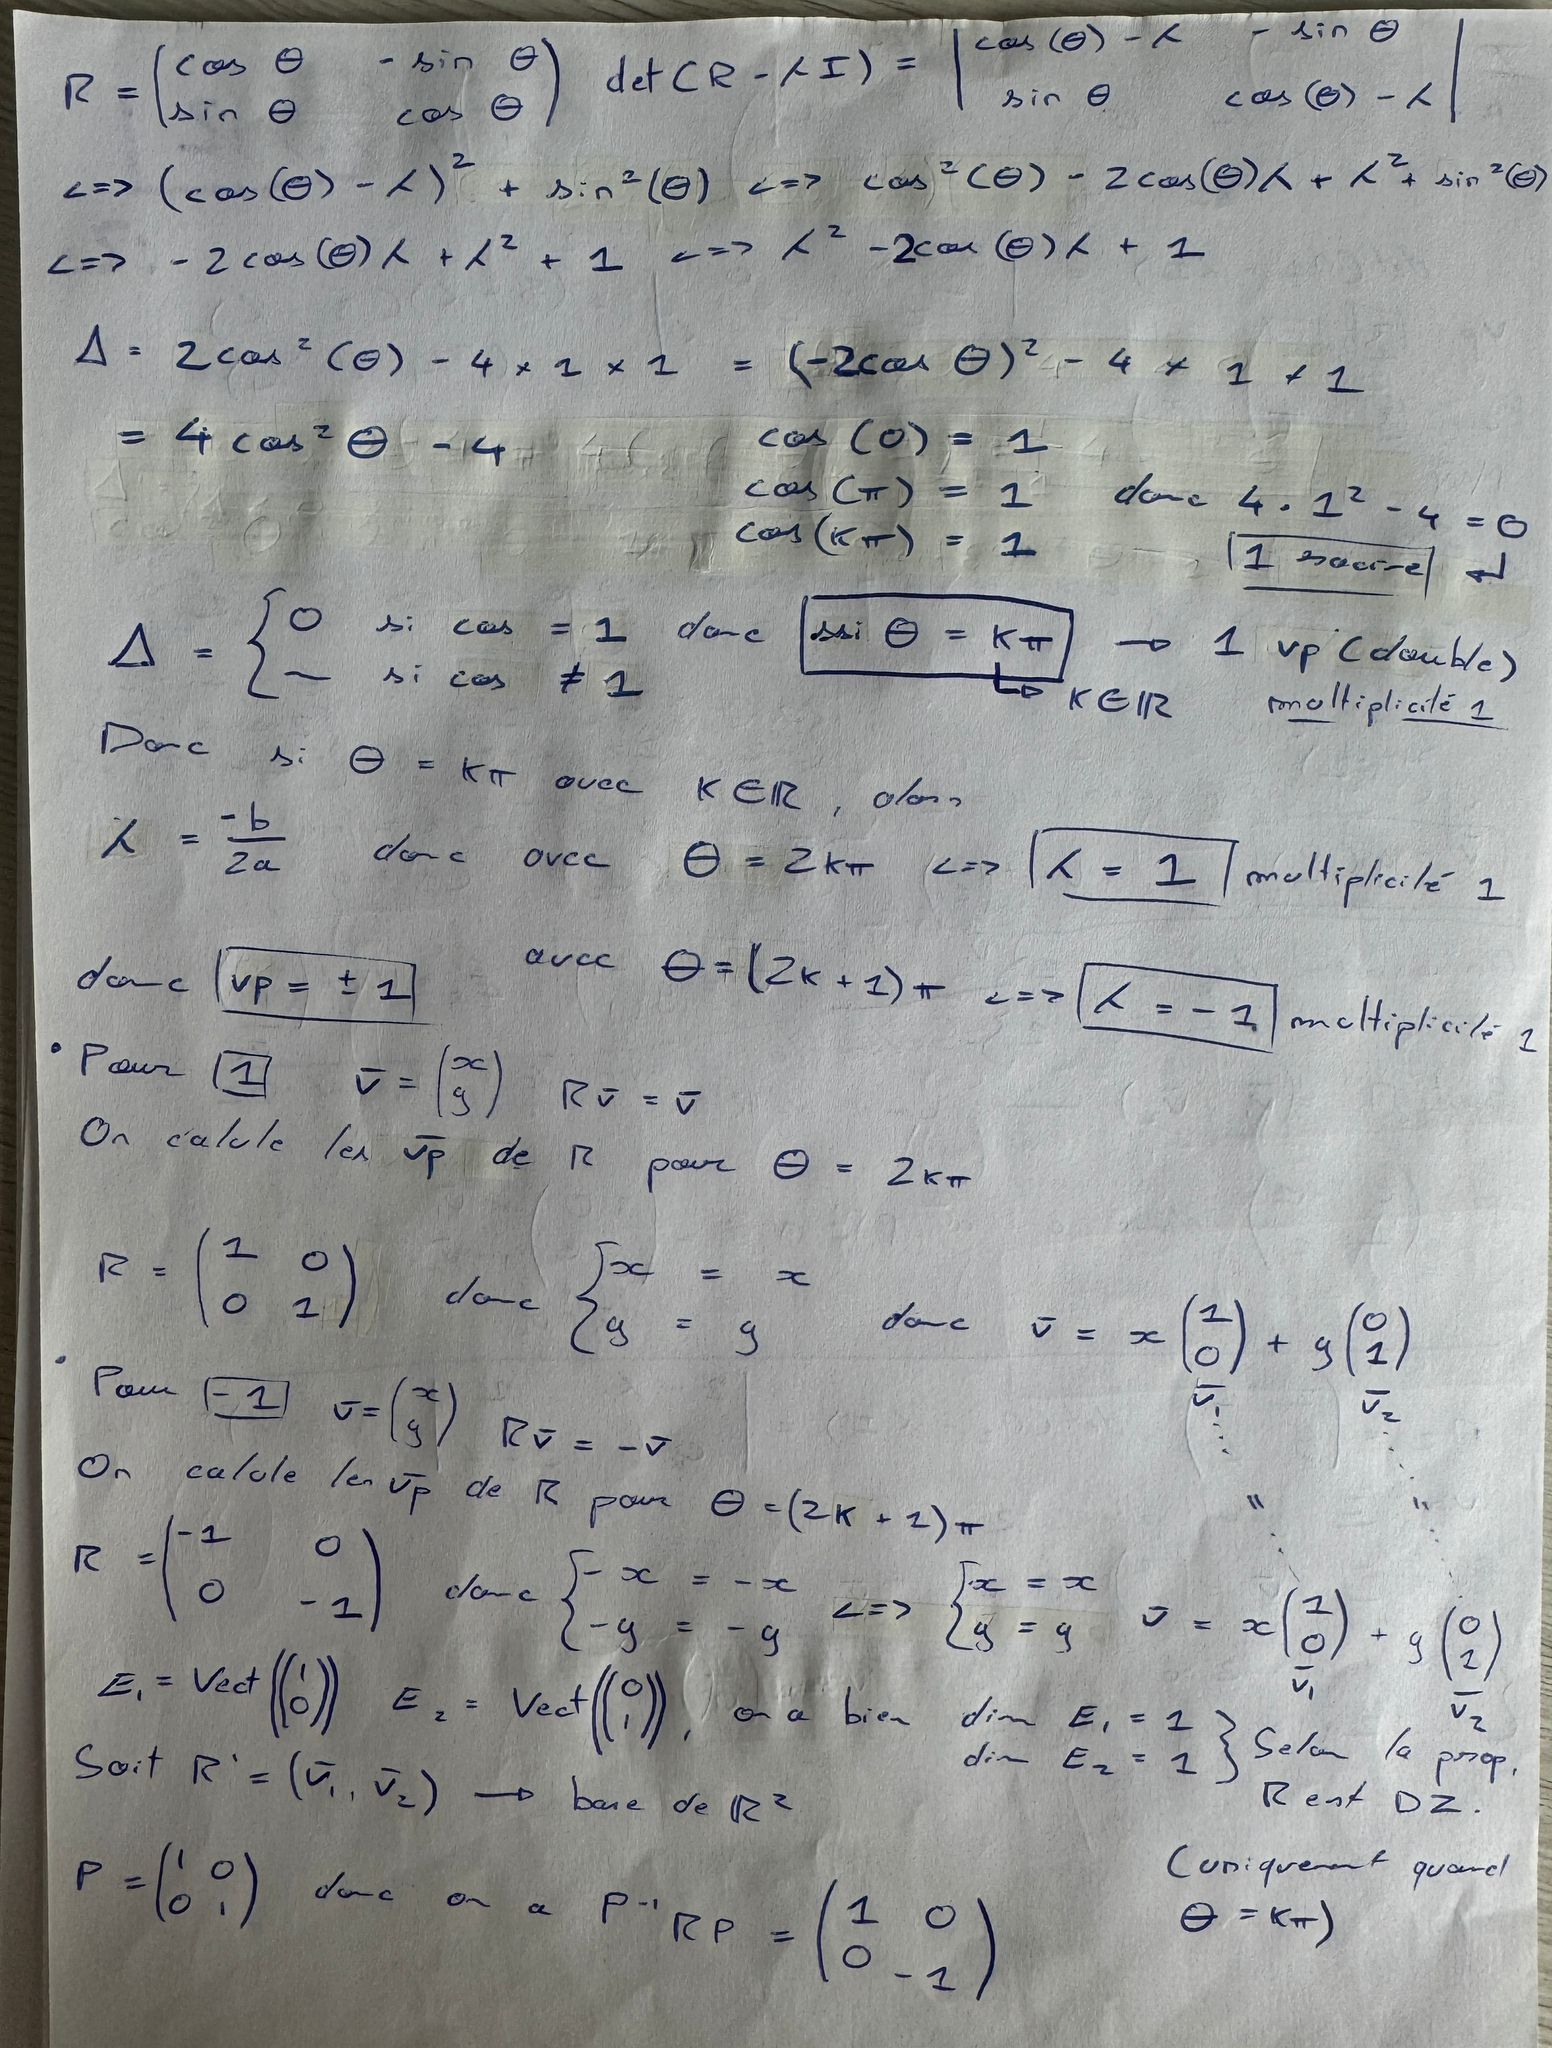

En vous basant sur les observations géométriques ainsi que sur votre calcul, déduire ce que représente la matrice R 

La matrice R correspond à une matrice de rotation d'angle theta (radian).

### 1.3 Transformation successives 2D

En prenant le vecteur $V=[1,0]$ et $\theta=\pi/10$, calculez $V= R*V$ 20 fois en boucle et tracez les 20 vecteurs calculés.

C:\Users\jorda\AppData\Local\Temp\ipykernel_36736\3511668725.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


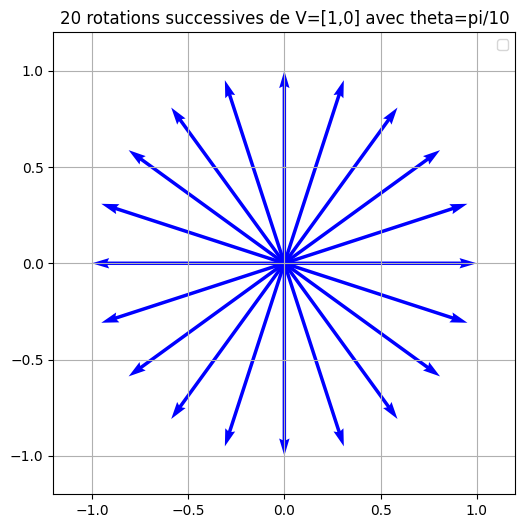

In [286]:
#*******************************************************************************
# écrire ci dessous la boucle qui calcule et affiche les 20 vecteurs
#******************************************************************************

V = np.array([1, 0])
theta = np.pi / 10

plt.figure(figsize=(6, 6))

for i in range(20):
    V = np.dot(R(theta), V)
    plt.quiver(0, 0, V[0], V[1], angles='xy', scale_units='xy', scale=1, color='blue')

plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.grid()
plt.gca().set_aspect('equal', adjustable='box')
plt.title('20 rotations successives de V=[1,0] avec theta=pi/10')
plt.legend()
plt.show()

### 1.4 Transformation linéaire en 3D

On considère maintenant la matrice $R_2$ :

$R_2 = \begin{pmatrix}
1 &0 &0 \\
0&cos(\theta) & -sin(\theta) \\
0&sin(\theta) & cos(\theta)
\end{pmatrix}$

🧩Adaptez l'implémentation de votre fonction transformation pour qu'elle prenne en compte les transforamtions 3D (elle devrait traiter à la fois les cas 2D et 3D). Puis testez, avec différentes valeurs de $\theta$, la transformation de vecteurs par $R_2$


💡 Pour tracer un vecteur X en 3D on pourrait écrire
```python
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot([0, X[0]], [0, X[1]], [0, X[2]])
```


💡 Pour interagir interactivement avec le graphique, vous pouvez rajouter la ligne suivante (ici ou au niveau des imports)
```pyhton
%matplotlib widget
```

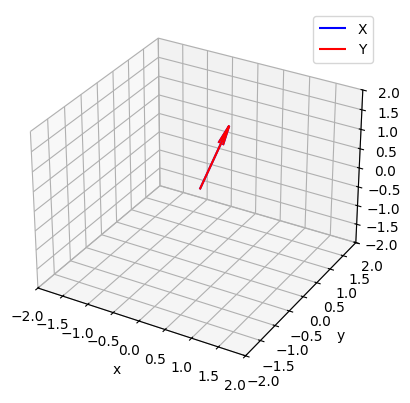

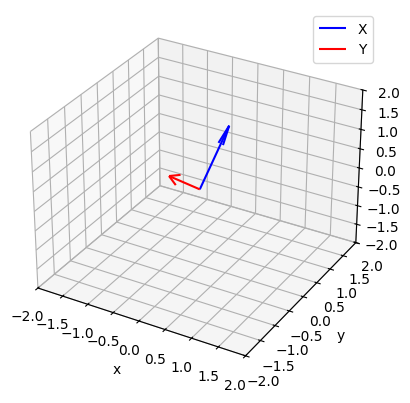

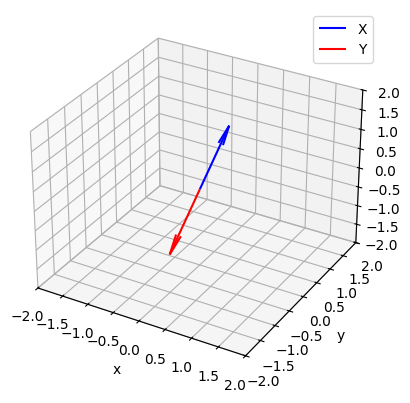

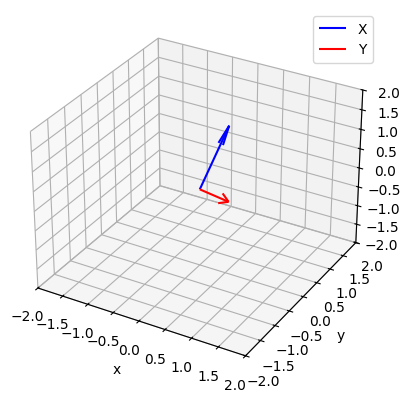

In [287]:
#*******************************************************************************
# écrire ci dessous le code qui teste les transformations par la matrice R2
#******************************************************************************

def R2(theta):
    return np.array([[1, 0, 0], [0, np.cos(theta), -np.sin(theta)], [0, np.sin(theta), np.cos(theta)]])

X = np.array([0, 1, 1])
M = R2(2 * np.pi) # 2pi ou 0 (0 degrés)
Y = transformation(M, X)
M = R2(np.pi / 2) # pi / 2 (90 degrés)
Y = transformation(M, X)
M = R2(np.pi) # pi (180 degrés)
Y = transformation(M, X)
M = R2(3 * np.pi / 2) # 3pi / 2 (270 degrés)
Y = transformation(M, X)

❓Que représente la matrice R2 ? Expliquez

La matrice R2 correspond à une matrice de rotation d'angle theta (radian), autour de l'axe des x.

🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹

## 2- Valeurs propres et vecteurs propres

✏️Donner la définition d'un vecteur propre et de sa valeur propre. Comment les calcule-t-on ?  

$\lambda$ est une valeur propre de l'application linéaire $f$, associée au vecteur propre $\vec{V} (\neq \vec{0})$ si et seulement si $f(\vec{V}) = \lambda \vec{V}$.

- Pour calculer les **valeurs propres**, nous devons résoudre l'équation caractéristique, c'est à dire trouver les $\lambda$ (racines), pour lesquelles
$det(M - \lambda I) = 0$.
- Pour calculer les vecteurs propres associés à ue valeur propre $\lambda_i$ donnée, nous devons résoudre le système $(M - \lambda I_n).X = 0$. L'ensemble des vecteurs propres assocités à une valeur propres $\lambda_i$ donnée, forme un sous-espace vectoriel de $E$.

Pour calculer les valeurs propres d'une matrice carrée en Python on utilise la fonction `np.linalg.eig` qui renvoie une vecteur contenant les valeurs propres, ainsi qu'une matrice constituée des vecteurs propres correspondant en colonne.

🧩Testez le programme ci-dessous.

In [288]:
A = np.array([[8,1,6],[3,5,7], [4,9,2]])
print(f'la matrice \n{A}\n')
val,vect= np.linalg.eig(A)
print(f'possède comme valeurs propres \n {val} \n')
print(f'avec les vecteurs propores correspondants \n {vect}\n')

la matrice 
[[8 1 6]
 [3 5 7]
 [4 9 2]]

possède comme valeurs propres 
 [15.          4.89897949 -4.89897949] 

avec les vecteurs propores correspondants 
 [[-0.57735027 -0.81305253 -0.34164801]
 [-0.57735027  0.47140452 -0.47140452]
 [-0.57735027  0.34164801  0.81305253]]



🧩Comment peut on vérifier si les vecteurs de la matrice `vect` sont bien des vecteurs propres de `A` ?

In [289]:
#*******************************************************************************
# écrire ci dessous quelques instrucitons permettant de vérifier que les colonnes
# de vect sont bien des vecteurs propres associés aux valeurs de val
#******************************************************************************

for i in range(len(val)):
    v = vect[:, i] # ieme vecteur propre
    lambda_i = val[i] # ieme valeur propre

    Av = np.dot(A, v)
    lv = lambda_i * v

    print("Valeur propre", val[i], " :")
    print(Av)
    print(lv)
    print()

Valeur propre 15.000000000000004  :
[-8.66025404 -8.66025404 -8.66025404]
[-8.66025404 -8.66025404 -8.66025404]

Valeur propre 4.898979485566359  :
[-3.98312766  2.30940108  1.67372659]
[-3.98312766  2.30940108  1.67372659]

Valeur propre -4.8989794855663575  :
[ 1.67372659  2.30940108 -3.98312766]
[ 1.67372659  2.30940108 -3.98312766]



❓Soit `D` la matrice diagonale contenant les valeurs propres de `A`. Quelle est la relation entre `A`, `D` et `vect` ?


La relation entre $A$, $D$ et $vect$ ($P$), est $M = PDP^{-1}$ Avec $P = vect$ et $P^{-1}$ inverse de $vect$

🧩 Vérifiez cette relation par le code

In [290]:
#*******************************************************************************
# écrire ci dessous un code sui vérifie la relation entre A, vect et D
#******************************************************************************

#--------------------------------------------------
#calcul de D
D = np.diag(val)

#--------------------------------------------------
# vérifiaction de la relation

P = vect # Matrice de passage

Abis = np.dot(np.dot(P, D), np.linalg.inv(P)) # M = P.D.Pinv
print(A)
print(Abis)

[[8 1 6]
 [3 5 7]
 [4 9 2]]
[[8. 1. 6.]
 [3. 5. 7.]
 [4. 9. 2.]]


✏️ Calculez, à la main sur papier, les valeurs propres et vecteurs propres des matrices utilisées dans la première partie de ce TP, à savoir:

$M=\begin{pmatrix}
5/4 & 0 \\
-1/2 & 3/4
\end{pmatrix}
$  et $R = \begin{pmatrix}
cos(\theta) & -sin(\theta) \\
sin(\theta) & cos(\theta)
\end{pmatrix}$

Pour R exprimez d'abord le calcul en fonction de $\theta$ , et ensuite appliquez pour des valeurs pertinentes, sachant que nous recherchons des solutions réelles.

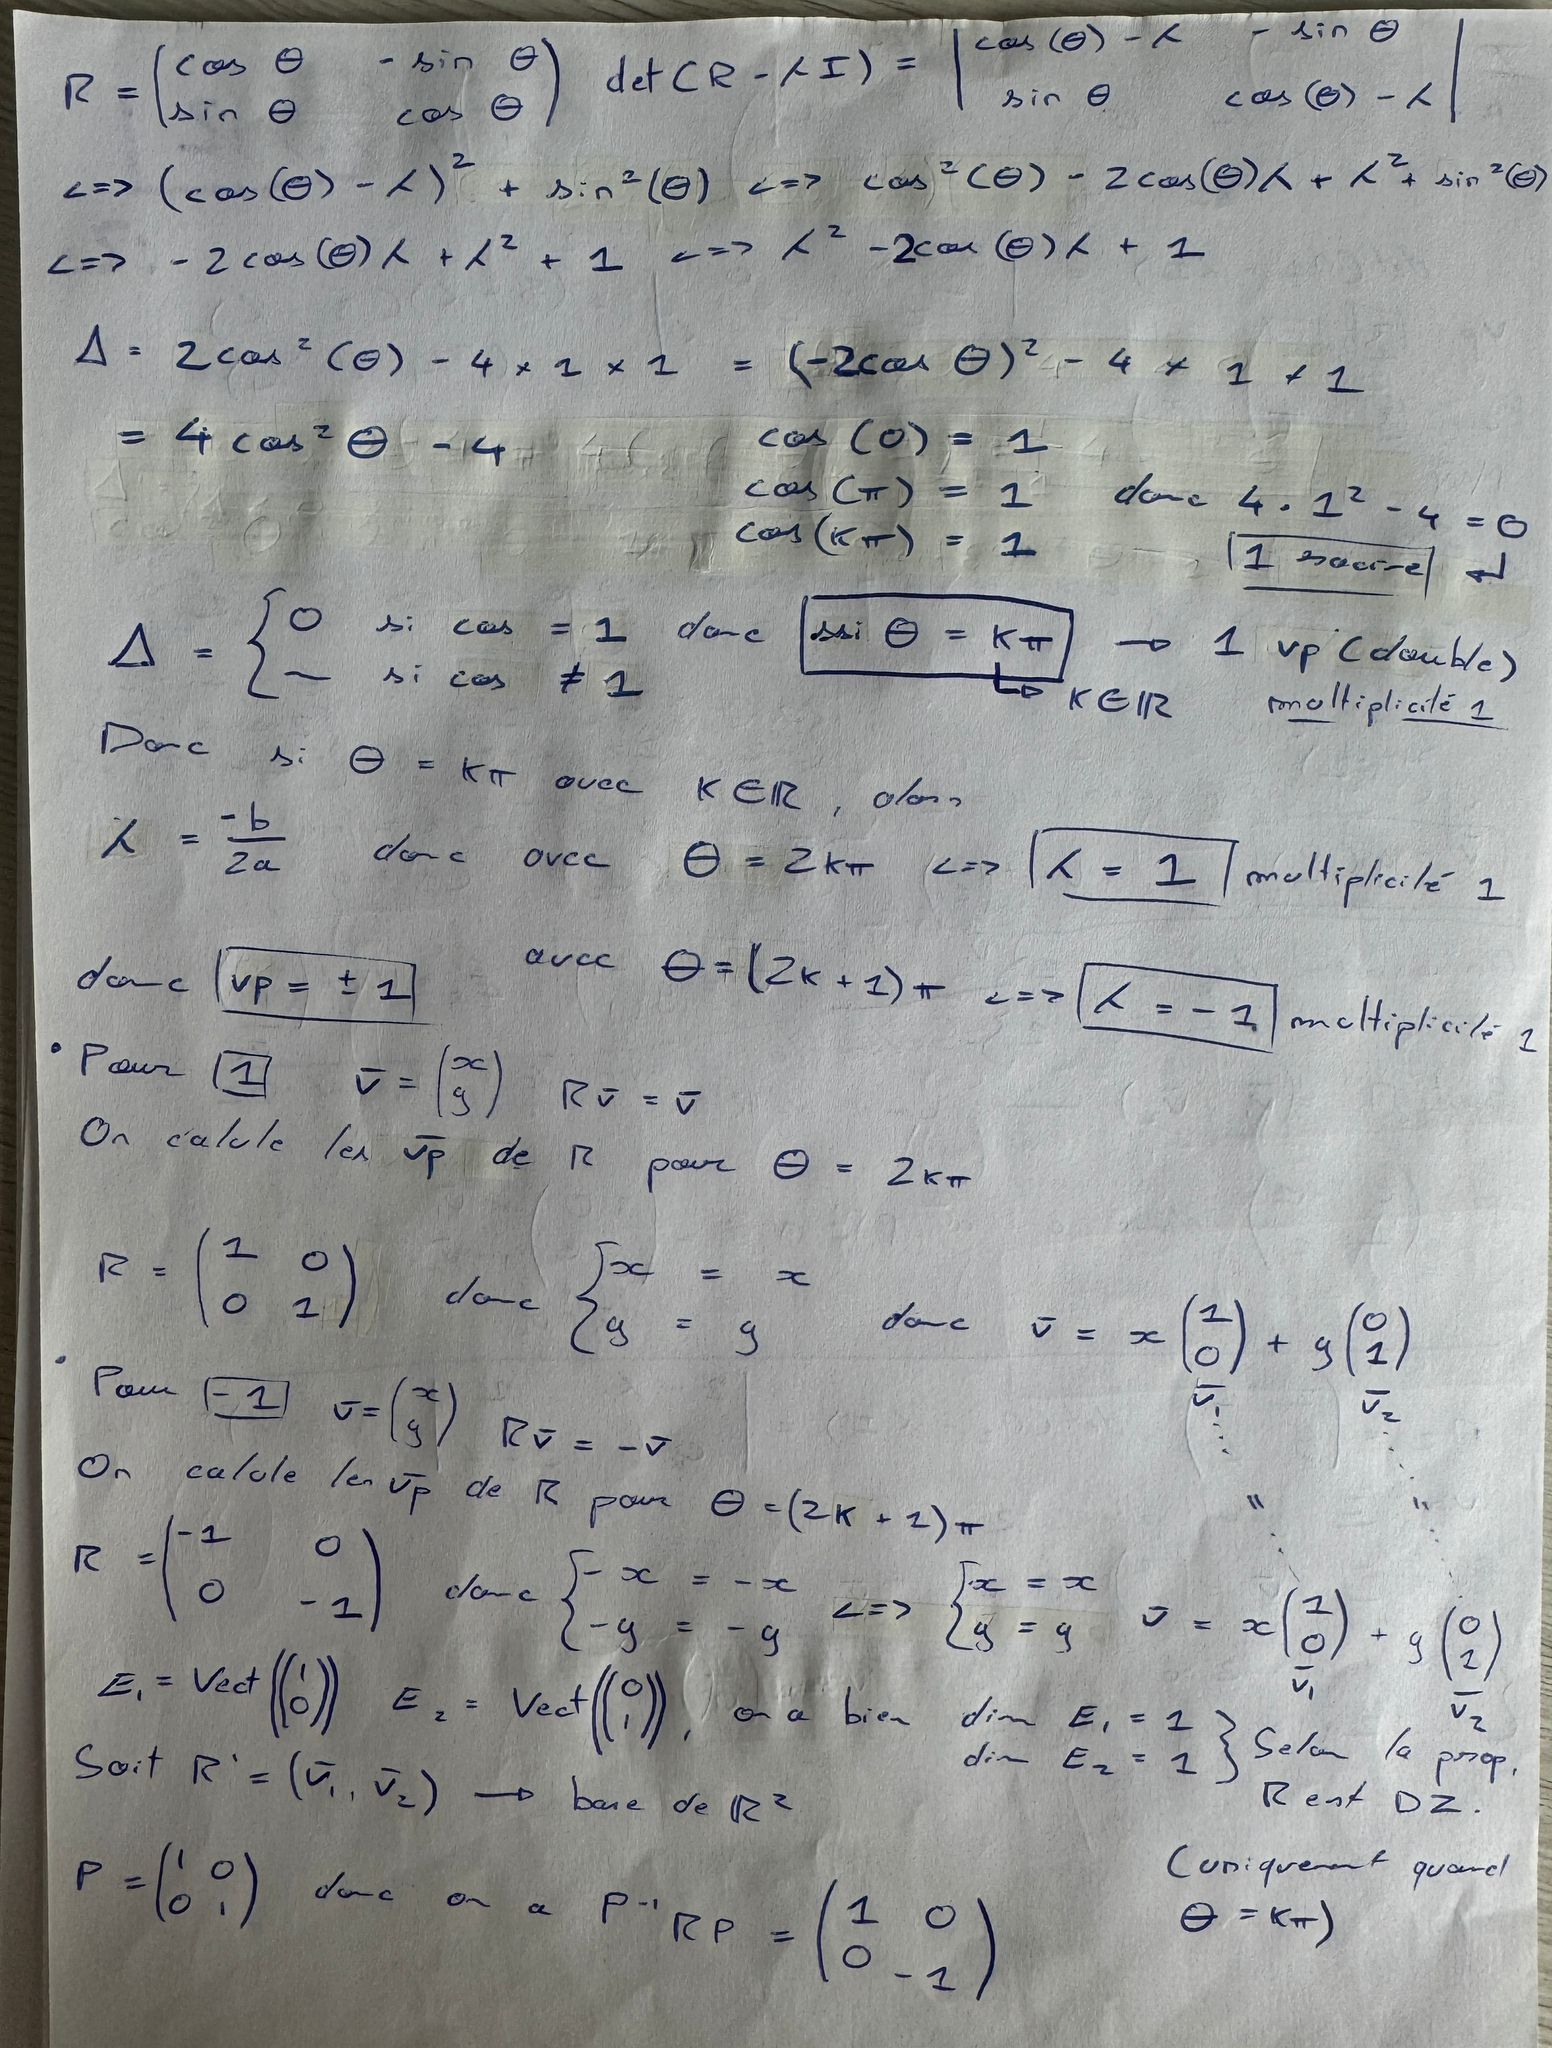

❓Interprétez géométriquement le cas de $R$

La matrice $R$ est une matrice de rotation d'angle theta (radian).

⚙️Avec le code ci dessous, calculez les vecteurs et valeurs propres des matrices M et R

In [291]:
#*******************************************************************************
#voici le code qui calcule les valeurs propres et vecteurs propres de
# M et R
#******************************************************************************
M = np.array([[5/4,0],[-1/2,3/4]])
valM,vectM= np.linalg.eig(M)
print(f'les vecteurs propores de M sont \n {vectM}')
print(f'avec les valeurs propres \n {valM}\n')


#testez avec différentes valeurs de theta 
theta = 0
R = np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])
valR,vectR= np.linalg.eig(R)

print(f'Pour theta = {theta}')
print(f'les vecteurs propores de R sont \n {vectR}')
print(f'avec les valeurs propres \n {valR}')


les vecteurs propores de M sont 
 [[ 0.          0.70710678]
 [ 1.         -0.70710678]]
avec les valeurs propres 
 [0.75 1.25]

Pour theta = 0
les vecteurs propores de R sont 
 [[1. 0.]
 [0. 1.]]
avec les valeurs propres 
 [1. 1.]


❓Comparez les résulats à ceux que vous aviez obtenus à la main et interprétez

Les résultats obtenues pour la matrice $M_1$ sont les mêmes (à condition de diviser les valeurs propres par 4 sur ma copie, puisque j'avais multiplé la matrice par 4 pour que ce soit plus pratique). Mes vecteurs propres sont colinéaires aux vecteurs propres obtenues par le calcul effectué sur Python (qui approximatise les résultats).

Les résultats obtenues par la matrice $R$ sont identiques.

🛠️Mêmes questions pour $N=\begin{pmatrix}
2 & 1 \\
0 & 2
\end{pmatrix}
$ 
Calculez les vecteurs et valeurs propres, d'abord à la main ✏️ puis numériquement 🧩et comparez

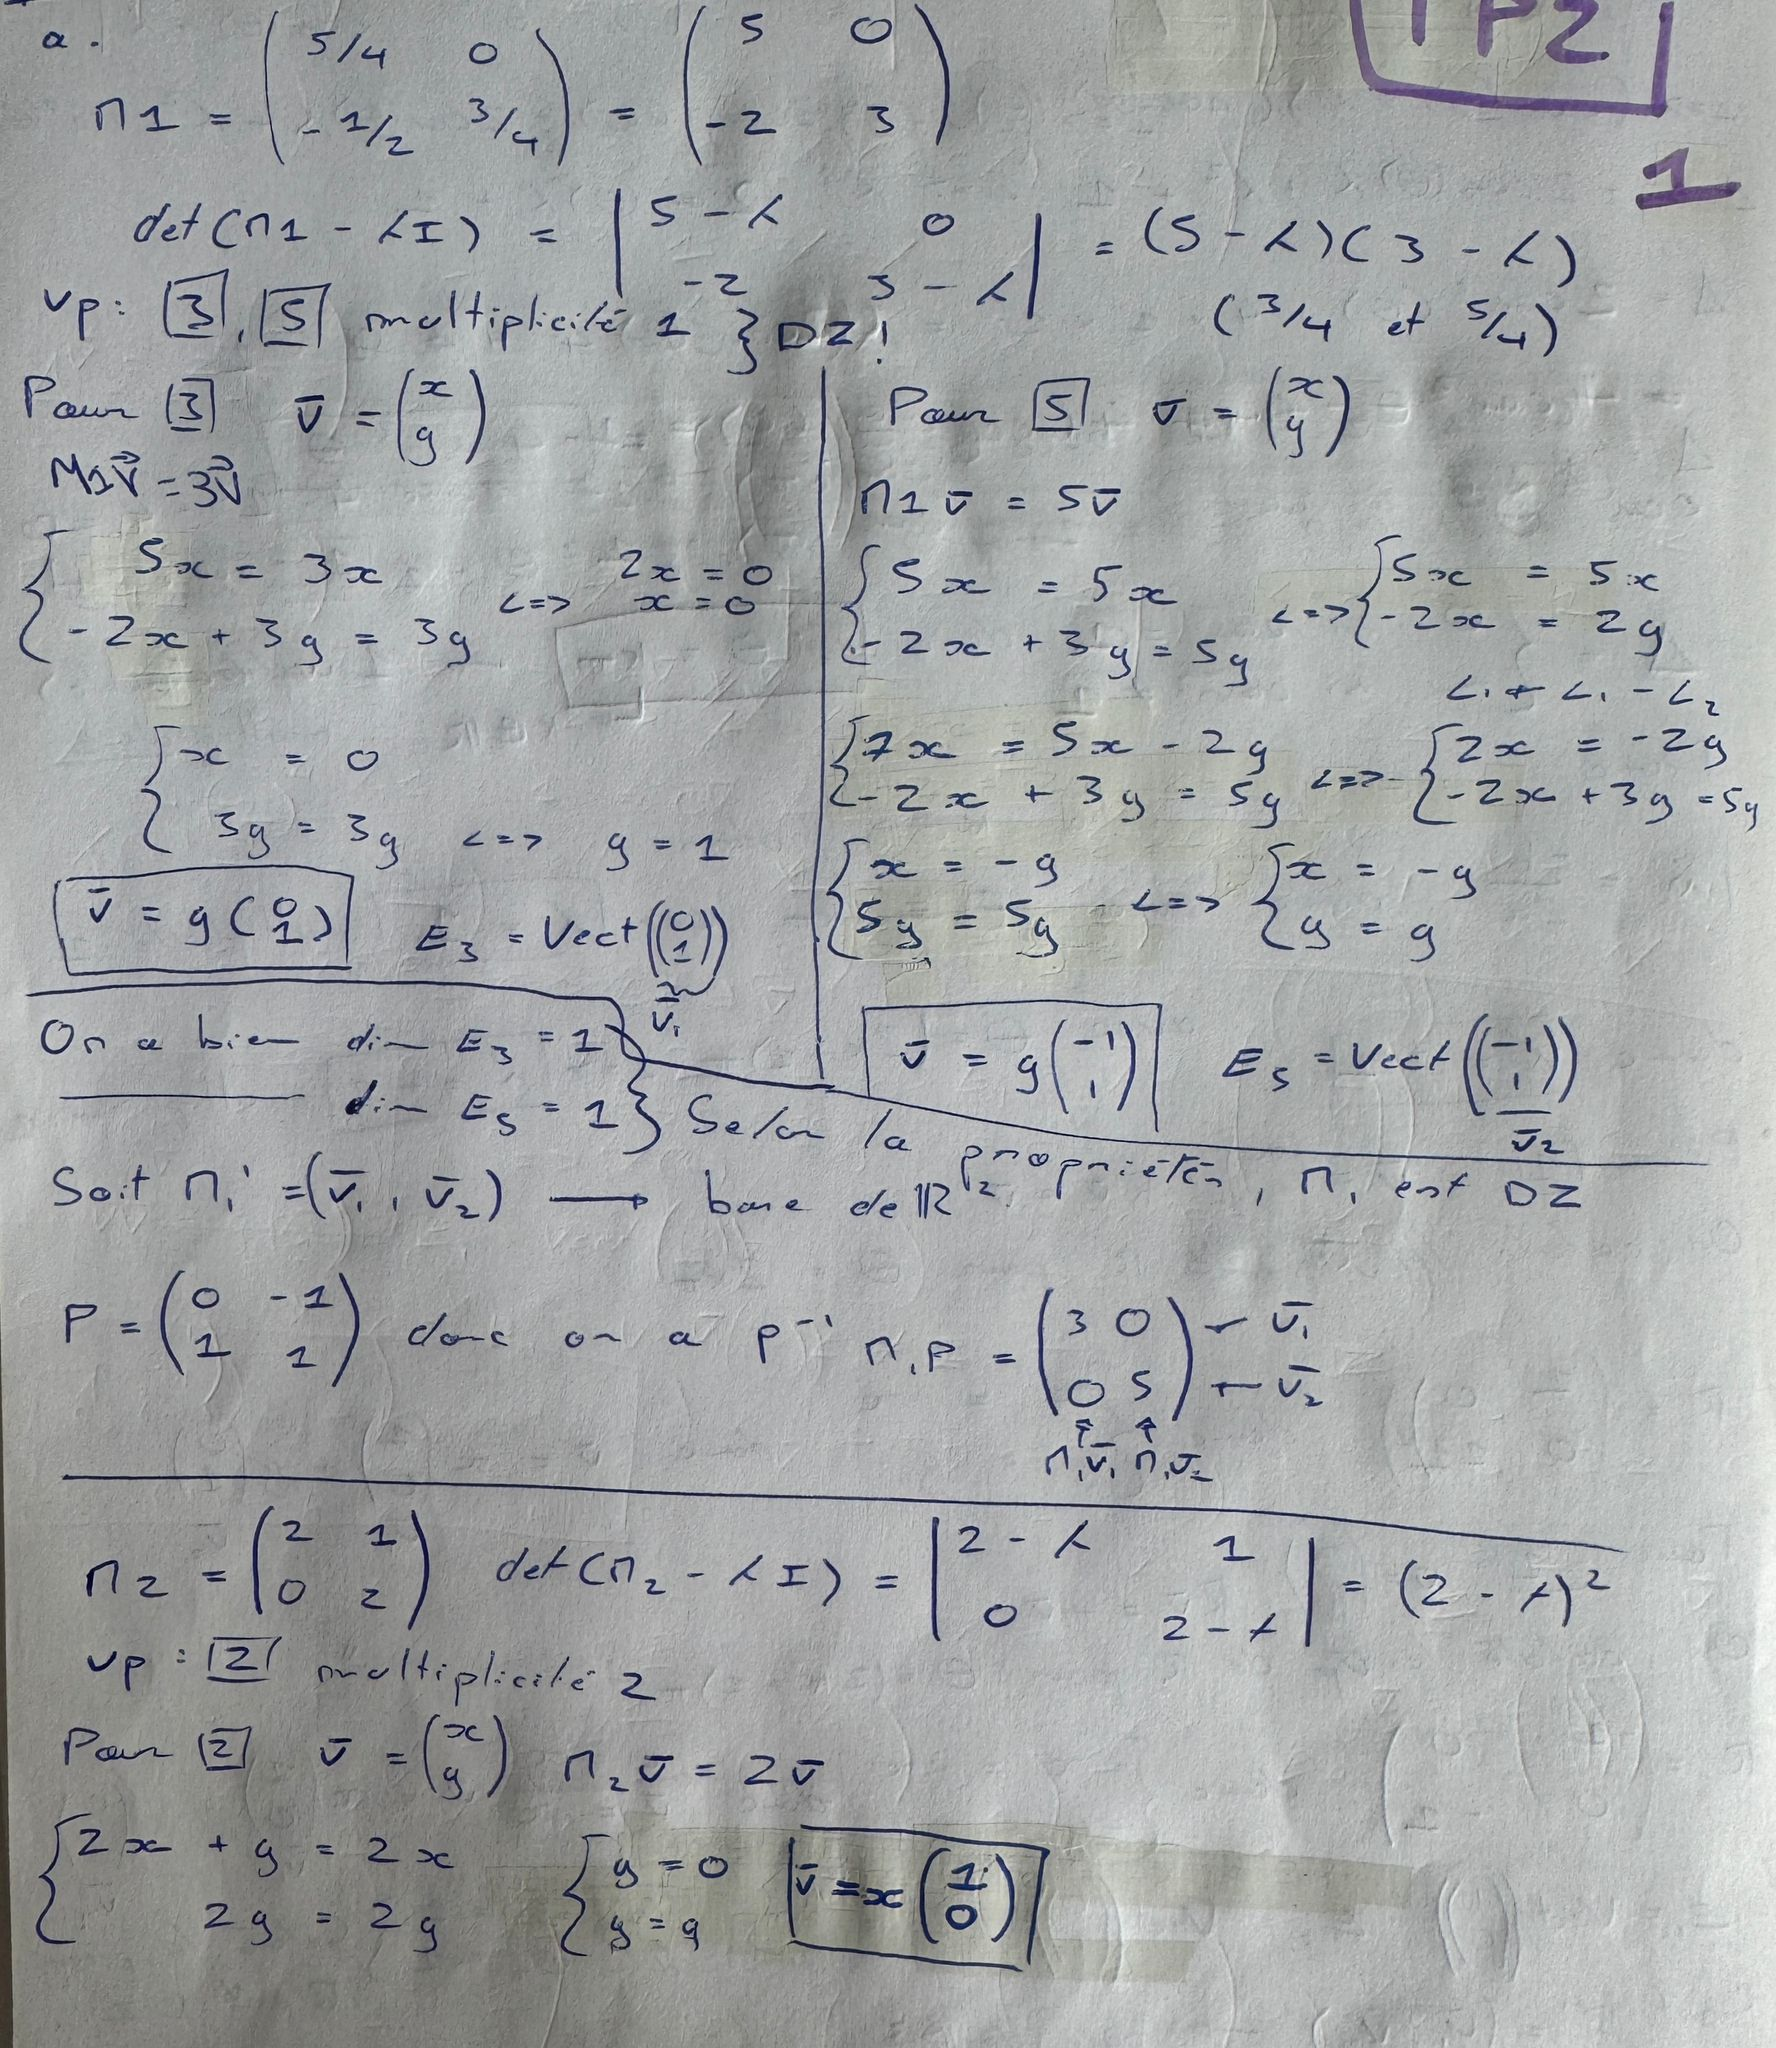

In [292]:
#*******************************************************************************
# écrire ci dessous le code qui calcule les valeurs propres et vecteurs propres de
# la nouvelle matrice N
#*******************************************************************************

N = np.array([[2, 1],[0, 2]])
valN,vectN = np.linalg.eig(N)
print(f'les vecteurs propores de N sont \n {vectN}')
print(f'avec les valeurs propres \n {valN}\n')

les vecteurs propores de N sont 
 [[ 1.0000000e+00 -1.0000000e+00]
 [ 0.0000000e+00  4.4408921e-16]]
avec les valeurs propres 
 [2. 2.]



J'ai bel et bien les mêmes valeurs propres (2 multiplicité 2). Cependant, j'ai qu'un seul vecteur propre correcte [1, 0], car j'ai calculé dans $\R$ uniquement.

❓Parmi les trois matrices précédentes M,R et N, lesquelles sont diagonalisables? **Justifier**

$M_1$ est diagonalisable dans $\R$ car ses valeurs propres sont différentes, et j'ai le bon nombre de vecteurs propres associés au multiplicité de chacunes des valeurs propres.

$M_2$ n'est pas diagonalisable dans $\R$ car je n'ai pas bon nombre de vecteurs propres associés à la multiplicité de sa valeur propre.

$R$ est diagonalisable uniquement lorsque $\theta = k\pi$ avec $k\in\R$, et que j'ai le bon nombre de vecteurs propres associés à la multiplicité de ses valeurs propres.

🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹

## 3- Applications

### 3.1 Résolution d'un système d'équations différentielles

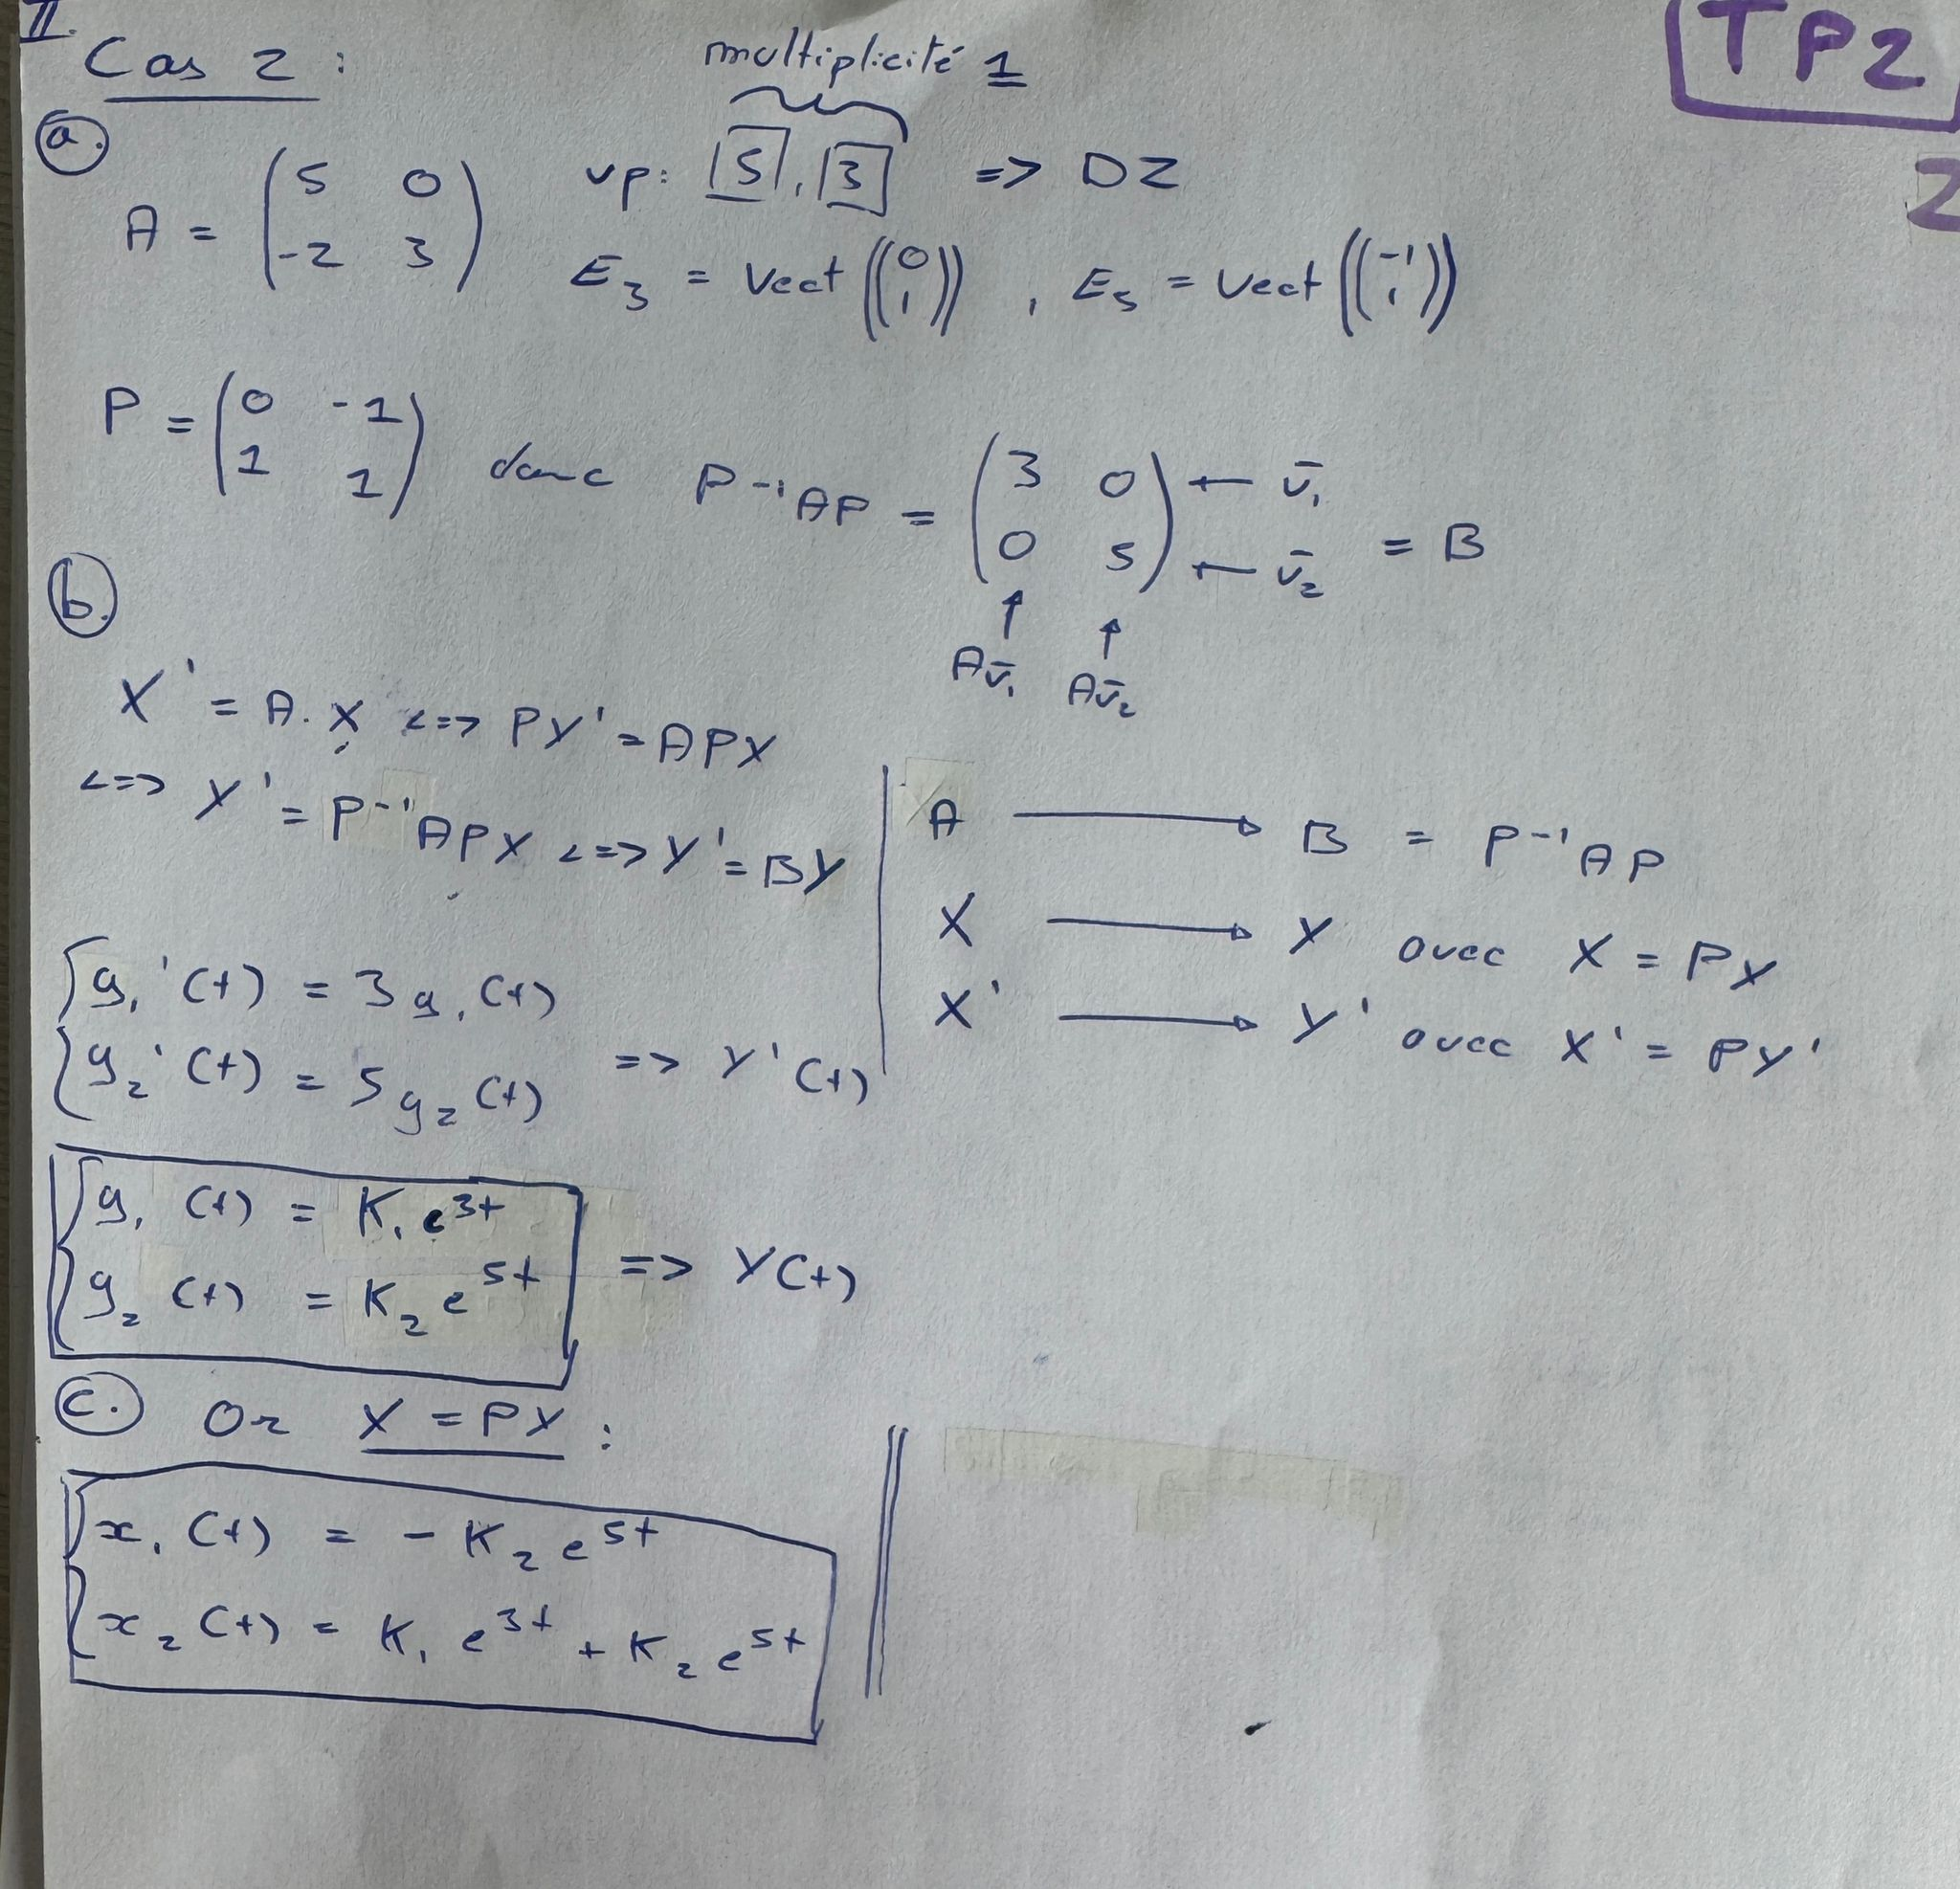

🧩Ecrivez une fonction `equaDiff` qui admet en paramètre d’entrée la matrice des coefficients ainsi que le vecteur de conditions initiales et qui trace les solutions entre 0 et 2. Testez

In [293]:
# écrire ici le corps de la fonction qui permet de résoudre le système
# d'équations différentielles dont les paramètres sont donnés par la
# matrice A et les conditions initiales par le vecteur X0

def equaDiff(A, X0):
    val, P = np.linalg.eig(A)
    P_inv = np.linalg.inv(P)
    
    t_vals = np.linspace(0, 2, 75)
    X_vals = []

    for t in t_vals:
        X_t = np.dot(np.dot(np.dot(P, np.diag(np.exp(val * t))), P_inv), X0) # Pe^{val.t}.P^-1.X
        X_vals.append(X_t)
    
    X_vals = np.array(X_vals)
    
    plt.figure()
    for i in range(len(X0)):
        plt.plot(t_vals, X_vals[:, i], label=f'X[{i}]')
    
    plt.xlabel('t')
    plt.ylabel('X(t)')
    plt.title("Solutions système d'équations différentielles")
    plt.legend()
    plt.grid()
    plt.show()
    
    return X_vals

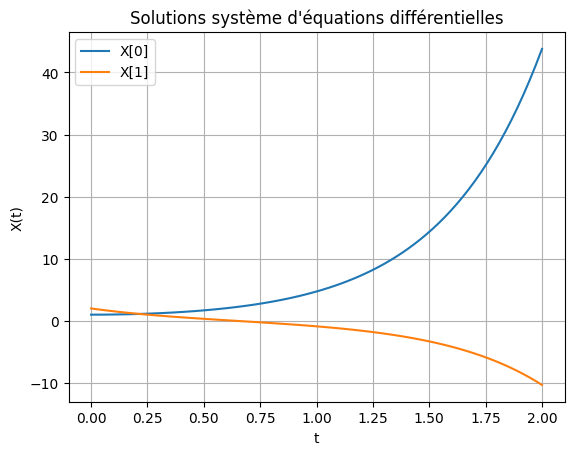

array([[ 1.00000000e+00,  2.00000000e+00],
       [ 1.00182671e+00,  1.86843600e+00],
       [ 1.00731350e+00,  1.74369817e+00],
       [ 1.01648042e+00,  1.62533080e+00],
       [ 1.02936097e+00,  1.51290142e+00],
       [ 1.04600220e+00,  1.40599930e+00],
       [ 1.06646490e+00,  1.30423387e+00],
       [ 1.09082385e+00,  1.20723335e+00],
       [ 1.11916802e+00,  1.11464335e+00],
       [ 1.15160097e+00,  1.02612560e+00],
       [ 1.18824120e+00,  9.41356713e-01],
       [ 1.22922256e+00,  8.60026989e-01],
       [ 1.27469478e+00,  7.81839299e-01],
       [ 1.32482399e+00,  7.06507991e-01],
       [ 1.37979332e+00,  6.33757848e-01],
       [ 1.43980361e+00,  5.63323084e-01],
       [ 1.50507410e+00,  4.94946372e-01],
       [ 1.57584324e+00,  4.28377903e-01],
       [ 1.65236959e+00,  3.63374476e-01],
       [ 1.73493273e+00,  2.99698605e-01],
       [ 1.82383429e+00,  2.37117657e-01],
       [ 1.91939907e+00,  1.75402998e-01],
       [ 2.02197621e+00,  1.14329158e-01],
       [ 2.

In [294]:
#*******************************************************************************
# appel de la fonction pour vérification
#*******************************************************************************
A = np.array([[2, -1], [-1, -2]])
X0 = np.array([1, 2])
equaDiff(A,X0)

### 3.2 Calcul d'une puissance matricielle

Calculer la puissance d’une matrice par des simples multiplications peut avoir un coût de calcul élevé pour de grandes matrices. Par exemple pour élever au carré une matrice de $N$x$N$ éléments il faut faire $N^3$  multiplications. 
    
Pour calculer sa $n^{ième}$ puissance il faut effectuer $(n-1) * N^3$ multiplications.
    
Une solution permettant la réduction du temps de calcul est la diagonalisation. En effet, élever une matrice diagonale à la puissance $n$ revient à élever, élément par élément, la diagonale : 

Si $A=\begin{pmatrix}
a_1 & & \\
& ... &\\
& & a_N
\end{pmatrix}$ alors   $A^n=\begin{pmatrix}
a_1^n & & \\
& ... &\\
& & a_N^n
\end{pmatrix}$

Cela revient à faire $(n-1)*N$ multiplications seulement.

✏️Soit $A$ une matrice diagonalisable, donnez l’expression de $A^n$  en fonction de la puissance de sa matrice diagonale.

$A^n = P^{-1}D^nP$

🧩Ecrivez une fonction calcPuissance qui admet en paramètre une matrice A et une puissance n et renvoie le résultat du calcul de $A^n$ en passant par la diagonalisation.

In [ ]:
#*******************************************************************************
# écrire ici le corps de la fonction qui calcule la puissance n de la
# matrice A par diagonaisation et renvoie le résultat 
#*******************************************************************************

def calcPuissance(A, n):
    vals, P = np.linalg.eig(A)

    Pinv = np.linalg.inv(P)
    Dn = np.diag(vals) ** n

    print(Pinv)
    print(Dn)

    return np.dot(np.dot(Pinv, Dn), P)

⚙️Le programme ci dessous calcule la puissance d'une matrice A par deux méthodes (en appelant votre fonction calcPuissance ou en utilisant la fonction `matrix_power` de numpy) et compare les résultats. Testez le avec chacune des deux matrices A1 et A2.

In [ ]:
#*******************************************************************
# calcul de la puissance avec deux méthodes
#*******************************************************************
A1 = np.array([[-1, 0, 0] , [0, -1, 0] ,[ 1, -1, 1]])
A2 = np.array([[-1, -2, 0],[ 2, -4, 1], [-1, 2, 0]])

A= A1; #choix de la matrice à tester 
n=8; #sélection de la puissance 

# la méthode de diagonalisation
AnDiag= calcPuissance(A,n)
# avec l'opérateur de puissance de Matlab
AnPow=np.linalg.matrix_power(A, n)

# test de conformité
if np.array_equal(AnDiag, AnPow):
    print("Calcul vérifié: Notre fonction donne le même résultat que l'opérateur de puissance");
else:
    print("Attention:notre fonction donne un résultat différent de celui de l'opérateur de puissance");


Calcul vérifié: Notre fonction donne le même résultat que l'opérateur de puissance


❓Le résultat donné par votre fonction est il toujours conforme à celui de `matrix_power` ? Expliquez

Non car l'approximation de Python peut parfois fausser les résultats.

Que remarquez vous pour les puissances de la matrice A1 selon si n est pair ou impair ? Pourquoi obtient on ces résultats ?

In [297]:
print("Puissance 2 : \n", calcPuissance(A1, 2))
print()
print("Puissance 3 : \n", calcPuissance(A1, 3))
print()
print("Puissance 4 : \n", calcPuissance(A1, 4))
print()
print("Puissance 5 : \n", calcPuissance(A1, 5))
print()

Puissance 2 : 
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Puissance 3 : 
 [[-1.          0.89442719  0.        ]
 [ 0.          1.          0.        ]
 [ 0.          0.         -1.        ]]

Puissance 4 : 
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Puissance 5 : 
 [[-1.          0.89442719  0.        ]
 [ 0.          1.          0.        ]
 [ 0.          0.         -1.        ]]



On remarque qu'avec des puissances paires, les matrices obtenies sont les matrices identités. Quand les puissances sont impaires, on obtient une autre matrice, qui est identique pour chaque $n$ impaire.

🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹

🗂️ <u>***Avant de rendre votre travail :***</u>
* ✅ *Exécutez toutes les cellules*
* ✅ *Assurez vous que tous vos résultats/figures sont bien visibles*
* ✅*Exportez le fichier en format **pdf***
* ✅ *Déposez le **pdf** sur e-campus*